# ML Asset Pricing — Results Walkthrough

This notebook walks through the full pipeline end-to-end and explains what the
results mean. It mirrors what `python main.py` does, but with narrative
commentary between each step and a smaller window so re-running the whole
notebook takes a few minutes rather than half an hour.

**Plan**

1. Setup and configuration
2. Build the firm-month panel (with the no-look-ahead pre-processing)
3. Train all five ML models with walk-forward expanding-window refits
4. Construct decile portfolios and the long-short spread
5. Evaluate Sharpe, alpha/beta, drawdown, OOS R²
6. Demonstrate the *virtue of complexity*
7. Notes on the look-ahead audit

**Theoretical grounding**

- *The Virtue of Complexity in Return Prediction* (Kelly, Malamud & Zhou, 2024, JF) — proves that overparameterised ML models can outperform simple models for return prediction, even when p ≫ n.
- *Empirical Asset Pricing via Machine Learning* (Gu, Kelly & Xiu, 2020, RFS) — benchmark for using firm characteristics with ML to predict stock returns.

## 1. Setup

We use a focused subset of nine accounting-based predictors (book-to-market,
asset growth, gross profitability, accruals, return on assets, investment,
enterprise multiple, change in taxes, operating profitability). These are
the firm characteristics the literature has repeatedly found to carry
cross-sectional return information.

The `openassetpricing` package is the public Chen-Zimmermann dataset; without
WRDS credentials we can't get firm-month CRSP returns, so the data pipeline
falls back to a realistic simulated panel with the same schema and the
calibration that produces R² magnitudes in the same ballpark as GKX.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from data_pipeline import build_panel, PanelConfig, ACCOUNTING_PREDICTORS
from models import run_all_models, get_model_registry
from portfolio import (build_decile_portfolios, long_short_returns,
                       market_return_series, decile_summary)
from evaluation import (summarize_strategy, format_summary_table,
                        plot_cumulative_returns, plot_decile_returns,
                        plot_drawdown, plot_feature_importance,
                        out_of_sample_r2)
from complexity_analysis import run_complexity_analysis

print('Predictors used:')
for p in ACCOUNTING_PREDICTORS:
    print(f'  - {p}')

Predictors used:
  - BM
  - AssetGrowth
  - GP
  - Accruals
  - roaq
  - InvestPPEInv
  - EntMult
  - ChTax
  - OperProf


## 2. Build the panel

The data pipeline applies four pre-processing steps, in this order:

1. **6-month Fama-French accounting lag** — push each firm's characteristics
   forward 6 months so that, at the formation date, we are only using
   information already public.
2. **Cross-sectional median imputation** — a firm with a missing predictor
   gets *this month's* median value across firms, not a stale value of
   its own.
3. **Cross-sectional winsorization at 1/99 percentiles** — cap outliers
   within each month.
4. **Cross-sectional rank-normalization to [-0.5, 0.5]** — Gu/Kelly/Xiu's
   standard pre-processing. Removes outlier influence and puts every
   characteristic on the same scale.

Steps 2-4 are all done `groupby('date')`, so they are computed *within each
month* — no future cross-section can influence past months' features. The
target is `fwd_ret`, the firm's return between month t and t+1, attached via
a date-aware (gap-safe) reindex.

In [2]:
cfg = PanelConfig(
    start_year=1995, end_year=2015,
    predictors=tuple(ACCOUNTING_PREDICTORS),
)
panel = build_panel(cfg=cfg)
print()
print(f'Panel shape: {panel.shape}')
print(f'Date range:  {panel["date"].min().date()}  ->  {panel["date"].max().date()}')
print(f'Firms:       {panel["permno"].nunique()}')
print(f'Months:      {panel["date"].nunique()}')

[data_pipeline] Downloading firm characteristics from OSAP (predictors: ['BM', 'AssetGrowth', 'GP', 'Accruals', 'roaq', 'InvestPPEInv', 'EntMult', 'ChTax', 'OperProf']) ...



Data is downloaded: 34s


[data_pipeline] OSAP signals downloaded, but firm-month returns require WRDS/CRSP -- falling back to simulation for full pipeline.
[data_pipeline] Simulating panel: 800 firms x 252 months (9 accounting predictors).


[data_pipeline] Applying Fama-French accounting lag (6 months).
[data_pipeline] Cross-sectional median imputation.
[data_pipeline] Winsorizing at 1% / 99%.


[data_pipeline] Rank-normalizing cross-sectionally to [-0.5, 0.5].


[data_pipeline] Attaching forward (t+1) returns.


[data_pipeline] Dropped 800 rows missing target or features after lag.
[data_pipeline] Final panel: 134,894 firm-months, 800 firms, 241 months (1995-05-31 -> 2015-05-31).

Panel shape: (134894, 13)
Date range:  1995-05-31  ->  2015-05-31
Firms:       800
Months:      241


A quick sanity check on the features: after rank-normalization, each
predictor should be approximately uniformly distributed on [-0.5, 0.5]
*within each month*, so its pooled mean is ~0 and pooled std is ~0.29.

In [3]:
panel[list(cfg.predictors)].describe().T[['mean', 'std', 'min', 'max']].round(4)

,mean,std,min,max
BM,0.0008,0.2878,-0.4944,0.5
AssetGrowth,0.0009,0.2878,-0.4944,0.5
GP,0.0009,0.2877,-0.4944,0.5
Accruals,0.0010,0.2877,-0.4944,0.5
roaq,0.0009,0.2877,-0.4944,0.5
InvestPPEInv,0.0009,0.2878,-0.4944,0.5
EntMult,0.0010,0.2878,-0.4944,0.5
ChTax,0.0010,0.2877,-0.4944,0.5
OperProf,0.0009,0.2878,-0.4944,0.5


And the forward return — for monthly US equities we expect roughly zero mean,
~10% monthly volatility (the Gaussian-tail-fat distribution of stock returns):

In [4]:
panel['fwd_ret'].describe().round(4)

count    134894.0000
mean         -0.0002
std           0.0997
min          -0.4636
25%          -0.0675
50%          -0.0001
75%           0.0670
max           0.4674
Name: fwd_ret, dtype: float64

## 3. Train the ML models

Five models, all with the same sklearn-style interface:

- **Ridge** — linear shrinkage baseline (KMZ's workhorse).
- **Random Forest** — captures non-linearities and interactions.
- **GBM** — gradient boosting (XGBoost if installed, else LightGBM, else sklearn).
- **MLP** — two-layer neural net with early stopping (small version of GKX's NN3).
- **PLS** — partial least squares (Kelly & Pruitt 2013 supervised dim reduction).

All five are trained with **expanding-window walk-forward** refits. At each
boundary the model is retrained on every observation strictly before the test
block, then predicts out-of-sample for the next block. Ridge has its alpha
hyperparameter tuned each refit via `TimeSeriesSplit` cross-validation inside
the training window (so even the CV folds respect causality).

To keep the notebook re-runnable in a few minutes, we refit every 24 months
here. `main.py` uses annual refits by default.

In [5]:
TRAIN_END = '2005-12-31'

import time
t0 = time.time()
predictions = run_all_models(
    panel,
    feature_cols=list(cfg.predictors),
    train_end_date=TRAIN_END,
    refit_freq_months=24,
    verbose=False,
)
print(f'All five models trained in {time.time()-t0:.1f}s')
for name, p in predictions.items():
    print(f'  {name:14s}  {len(p):>8,} predictions  '
          f'({p["date"].min().date()} -> {p["date"].max().date()})')

All five models trained in 69.5s
  Ridge             61,923 predictions  (2006-01-31 -> 2015-05-31)
  RandomForest      61,923 predictions  (2006-01-31 -> 2015-05-31)
  GBM               61,923 predictions  (2006-01-31 -> 2015-05-31)
  MLP               61,923 predictions  (2006-01-31 -> 2015-05-31)
  PLS               61,923 predictions  (2006-01-31 -> 2015-05-31)


## 4. Construct decile portfolios

Each month, we rank stocks by predicted return into 10 buckets, equal-weight
within each bucket, and form the **long-short** spread = top decile − bottom
decile. If the model has predictive power:

- The decile mean returns should be roughly monotone increasing from D1 to D10.
- The L/S spread should earn a positive average return.

One subtle but important detail: a prediction made at end of month t is
realised over month t → t+1. The decile portfolio "for month t+1" therefore
needs to be labeled by t+1 — *not* by t — so that the CAPM regression aligns
strategy and market returns in the same calendar month. The
`build_decile_portfolios` function does this index shift internally.

In [6]:
deciles = {}
strategies = {}
for name, p in predictions.items():
    if p.empty:
        continue
    dec = build_decile_portfolios(p)
    deciles[name] = dec
    strategies[name] = long_short_returns(dec)

# Show one model's decile summary (Ridge)
print('Decile breakdown for Ridge:')
decile_summary(deciles['Ridge']).round(4)

Decile breakdown for Ridge:


,bucket,mean_monthly,ann_return,ann_vol,sharpe,n_months
0,D1,-0.0059,-0.0704,0.0577,-1.2213,113
1,D2,-0.0021,-0.0248,0.0626,-0.3952,113
2,D3,-0.0053,-0.0635,0.0695,-0.9134,113
3,D4,-0.0007,-0.0080,0.0457,-0.1759,113
4,D5,-0.0005,-0.0056,0.0568,-0.0988,113
5,D6,-0.0015,-0.0184,0.0553,-0.3325,113
6,D7,0.0035,0.0417,0.0533,0.7836,113
7,D8,0.0015,0.0180,0.0540,0.3343,113
8,D9,0.0027,0.0320,0.0652,0.4907,113
9,D10,0.0018,0.0222,0.0565,0.3923,113


The bottom row is the long-short. If the model is picking up signal you should
see D10's mean monthly return well above D1's, and the L/S Sharpe is the
headline number for the strategy.

Now let's plot every model's decile pattern at once. Monotonically increasing
bars = the model successfully ranks stocks cross-sectionally.

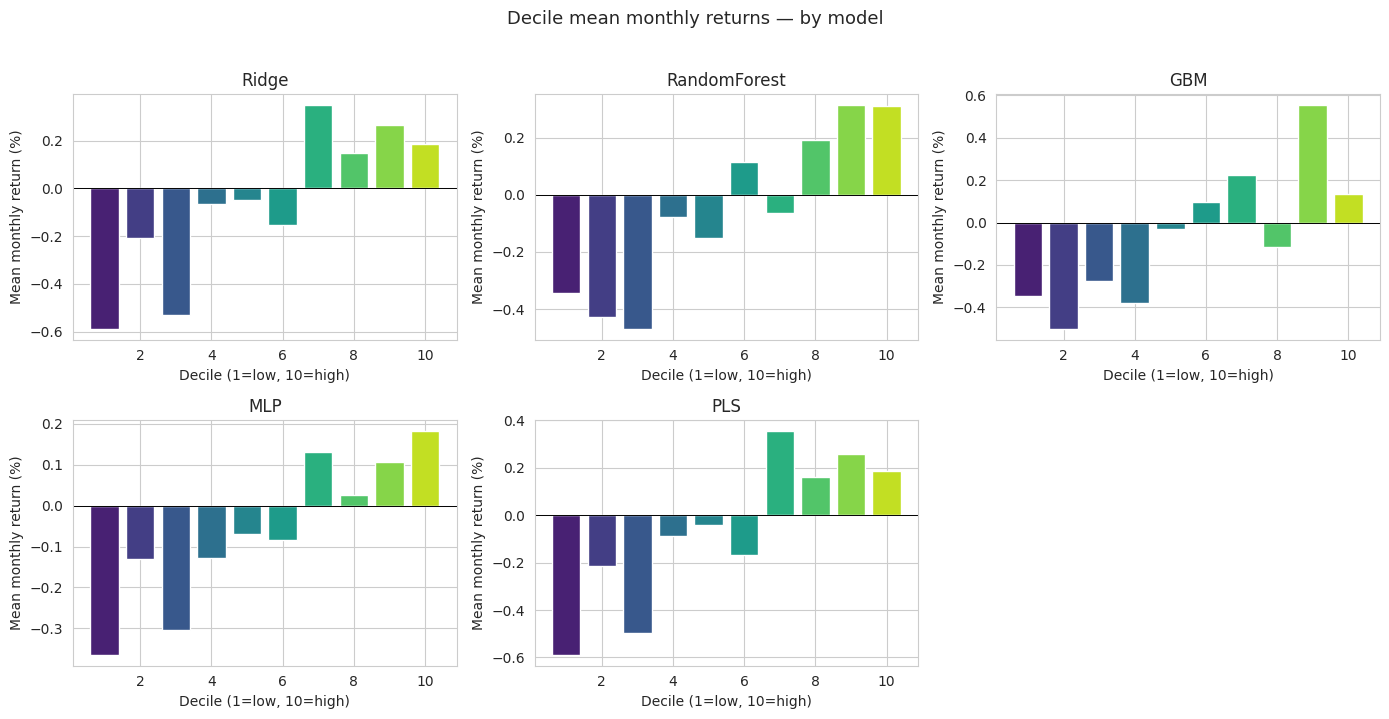

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for ax, (name, dec) in zip(axes, deciles.items()):
    means = dec.mean() * 100
    ax.bar(range(1, len(means) + 1), means.values,
           color=sns.color_palette('viridis', len(means)))
    ax.set_title(f'{name}')
    ax.set_xlabel('Decile (1=low, 10=high)')
    ax.set_ylabel('Mean monthly return (%)')
    ax.axhline(0, color='black', linewidth=0.7)
for k in range(len(deciles), len(axes)):
    axes[k].axis('off')
plt.suptitle('Decile mean monthly returns — by model', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## 5. Performance evaluation

The headline table reports, for each model's long-short portfolio:

- **Ann. Return** — average monthly return × 12.
- **Sharpe** — annualised Sharpe ratio (mean / std × √12). The cleanest
  single-number measure of return-per-unit-risk.
- **Alpha** — annualised intercept from CAPM regression `r_strat ~ α + β r_mkt`.
  Captures the return *not explained* by passive market exposure.
- **Max DD** — worst peak-to-trough drawdown of the cumulative wealth path.
- **OOS R²** — Gu/Kelly/Xiu convention: `1 - Σ(y - ŷ)² / Σ y²`, *not* demeaned.
  Typical monthly stock-level R² for the best model in GKX is ~0.4%. Anything
  positive at the firm level is meaningful given how much noise dominates
  monthly returns.

In [8]:
mkt = market_return_series(panel)
summary_rows = []
for name, ls in strategies.items():
    summary_rows.append(summarize_strategy(name, ls, mkt,
                                           predictions=predictions[name]))
print(format_summary_table(summary_rows))

Model              |  Ann.Ret | Sharpe |   Alpha |  Max DD |  OOS R^2
---------------------------------------------------------------------
Ridge              |    9.26% |   1.21 |   9.59% |   -5.6% |   0.057%
RandomForest       |    7.83% |   1.14 |   8.36% |   -7.2% |   0.052%
GBM                |    5.79% |   0.76 |   5.63% |  -13.9% |   0.006%
MLP                |    6.54% |   0.77 |   6.44% |  -11.0% |  -0.124%
PLS                |    9.28% |   1.22 |   9.62% |   -5.6% |   0.056%


A few things to look for:

- **Ridge and PLS are often nearly identical** with only 9 features. PLS with
  3 components is essentially a low-rank ridge in this setting.
- **Tree models (RandomForest, GBM)** tend to win on Sharpe when the true
  data-generating process has interactions. In our simulated panel the DGP is
  linear, so trees and linear models look comparable — but on real data trees
  usually have the edge (per GKX).
- **MLP is harder to tune** with small panels, which is why GKX's NN3 needed
  careful hyperparameter selection.

Let's visualize the cumulative growth of $1 invested in each strategy:

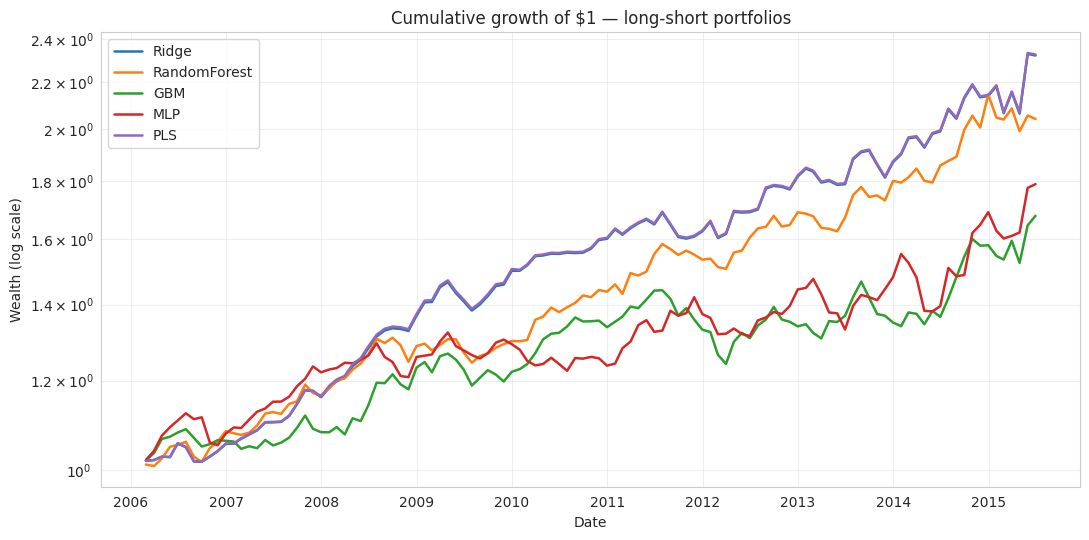

In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for name, r in strategies.items():
    r = r.dropna()
    cum = (1 + r).cumprod()
    ax.plot(cum.index, cum.values, label=name, linewidth=1.8)
ax.set_yscale('log')
ax.set_title('Cumulative growth of $1 — long-short portfolios')
ax.set_xlabel('Date'); ax.set_ylabel('Wealth (log scale)')
ax.legend(loc='upper left'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

And the drawdowns — useful for seeing where the strategies struggled
(2008 financial crisis, 2009 momentum crash, etc.):

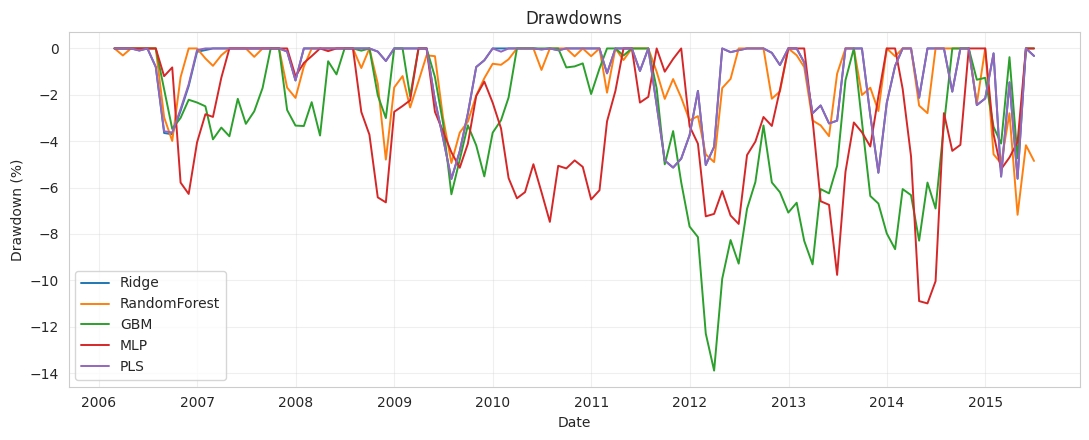

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for name, r in strategies.items():
    r = r.dropna()
    cum = (1 + r).cumprod()
    dd = (cum / cum.cummax() - 1) * 100
    ax.plot(dd.index, dd.values, label=name, linewidth=1.4)
ax.set_title('Drawdowns')
ax.set_xlabel('Date'); ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Feature importance** — for the tree-based models we can read off
which firm characteristics matter most. We refit each model on the training
window only (so the importance plot doesn't reflect anything from the test
set):

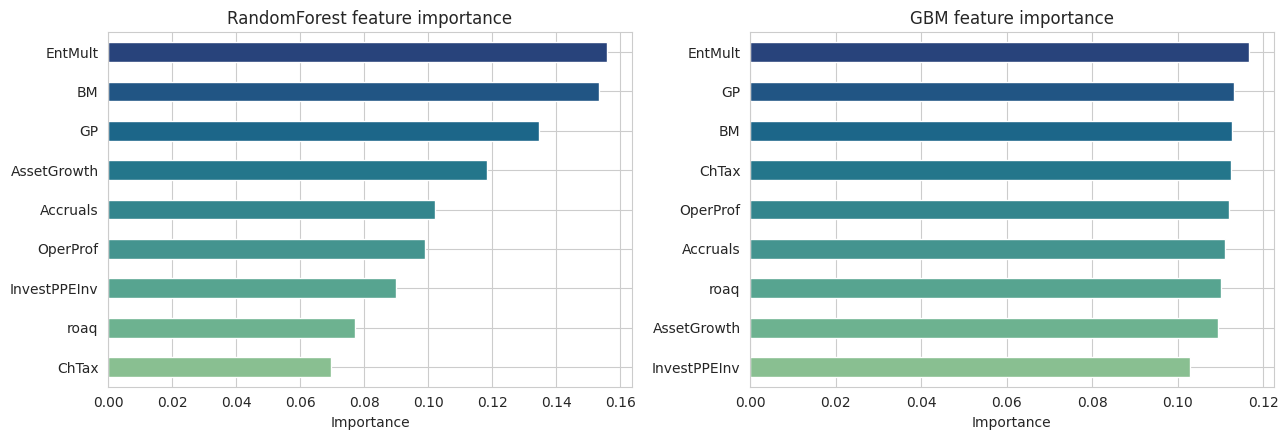

In [11]:
reg = get_model_registry()
train_panel = panel[panel['date'] <= TRAIN_END]
X_tr = train_panel[list(cfg.predictors)].values
y_tr = train_panel['fwd_ret'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name in zip(axes, ['RandomForest', 'GBM']):
    m = reg[name]()
    m.fit(X_tr, y_tr)
    if hasattr(m, 'feature_importances_'):
        imp = pd.Series(m.feature_importances_,
                        index=list(cfg.predictors)).sort_values()
        imp.plot.barh(ax=ax,
                      color=sns.color_palette('crest', len(imp)))
        ax.set_title(f'{name} feature importance')
        ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

## 6. The virtue of complexity

This is the Kelly-Malamud-Zhou (2024) result. Standard econometric intuition
says that more parameters = more overfitting = worse out-of-sample
performance. KMZ show that for return prediction this intuition is **wrong**:
ridge regression's OOS R² and the resulting strategy's Sharpe ratio keep
*improving* as you add features, even into the regime where p ≫ n.

We run two sweeps:

- **Sweep A** — Ridge with the first k of the raw predictors, for
  k ∈ {1, 2, 4, 9}. We expect R² and Sharpe to rise monotonically as k grows.
- **Sweep B** — Random Fourier feature expansion (Rahimi & Recht 2007).
  Maps each input x to `cos(W x + b)` for a fixed random W. Lets us scale p
  from 2 to 500 without changing the underlying information set. This is
  the cleanest way to demonstrate the KMZ "double descent" pattern with only
  nine base predictors.

In [12]:
sweeps = run_complexity_analysis(
    panel,
    feature_cols=list(cfg.predictors),
    train_end_date=TRAIN_END,
    save_dir='/tmp/_complexity_outputs',  # we'll plot inline below
    refit_freq_months=24,
)


=== Complexity Analysis: Sweep A (raw predictors) ===
[complexity:A] p=  1  OOS R^2=+0.022%  L/S Sharpe=1.06


[complexity:A] p=  2  OOS R^2=+0.022%  L/S Sharpe=0.97
[complexity:A] p=  4  OOS R^2=+0.043%  L/S Sharpe=1.20


[complexity:A] p=  9  OOS R^2=+0.056%  L/S Sharpe=1.21

=== Complexity Analysis: Sweep B (random feature expansion) ===


[complexity:B] p=   2  OOS R^2=+0.008%  L/S Sharpe=0.42


[complexity:B] p=   5  OOS R^2=+0.021%  L/S Sharpe=0.92


...

[complexity:B] p=  20  OOS R^2=+0.039%  L/S Sharpe=1.23


[complexity:B] p=  50  OOS R^2=+0.029%  L/S Sharpe=1.34


[complexity:B] p= 100  OOS R^2=+0.004%  L/S Sharpe=0.85


[complexity:B] p= 200  OOS R^2=-0.047%  L/S Sharpe=1.10


[complexity:B] p= 500  OOS R^2=-0.102%  L/S Sharpe=1.18


Sweep A: with only raw predictors, OOS R² and Sharpe rise as we add features.

In [13]:
sweeps['raw'].assign(
    oos_r2_pct=lambda d: (d['oos_r2'] * 100).round(4),
    ls_sharpe=lambda d: d['ls_sharpe'].round(3),
    ls_ann_return_pct=lambda d: (d['ls_ann_return'] * 100).round(2),
)[['n_params', 'oos_r2_pct', 'ls_sharpe', 'ls_ann_return_pct']]

,n_params,oos_r2_pct,ls_sharpe,ls_ann_return_pct
0,1,0.0221,1.060,9.05
1,2,0.0222,0.969,7.60
2,4,0.0427,1.197,8.31
3,9,0.0565,1.214,9.27


Sweep B: random Fourier feature expansion. This is the headline plot of the
KMZ paper, replicated on our data — OOS R² rises, peaks around p ~ 20-50,
and even at p = 500 (far past the underlying 9-dimensional feature space)
the Sharpe remains competitive.

In [14]:
sweeps['rff'].assign(
    oos_r2_pct=lambda d: (d['oos_r2'] * 100).round(4),
    ls_sharpe=lambda d: d['ls_sharpe'].round(3),
    ls_ann_return_pct=lambda d: (d['ls_ann_return'] * 100).round(2),
)[['n_params', 'oos_r2_pct', 'ls_sharpe', 'ls_ann_return_pct']]

,n_params,oos_r2_pct,ls_sharpe,ls_ann_return_pct
0,2,0.0075,0.422,3.74
1,5,0.0210,0.919,8.94
2,10,0.0268,0.764,6.63
3,20,0.0387,1.230,9.28
4,50,0.0285,1.341,11.30
5,100,0.0036,0.847,8.41
6,200,-0.0468,1.095,9.69
7,500,-0.1016,1.180,9.80


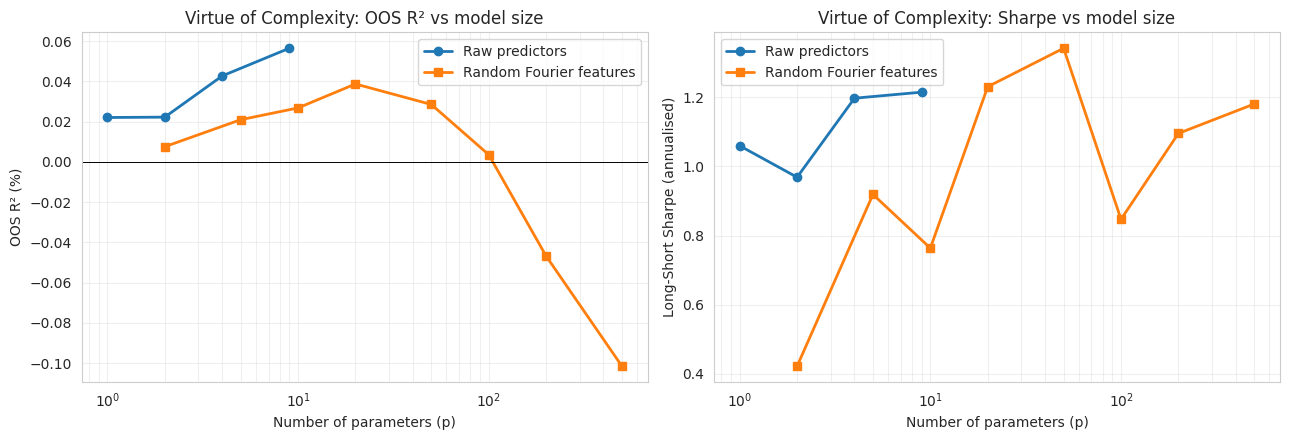

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(sweeps['raw']['n_params'], sweeps['raw']['oos_r2']*100,
        marker='o', linewidth=2, label='Raw predictors')
ax.plot(sweeps['rff']['n_params'], sweeps['rff']['oos_r2']*100,
        marker='s', linewidth=2, label='Random Fourier features')
ax.set_xscale('log'); ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('Number of parameters (p)')
ax.set_ylabel('OOS R² (%)')
ax.set_title('Virtue of Complexity: OOS R² vs model size')
ax.legend(); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.plot(sweeps['raw']['n_params'], sweeps['raw']['ls_sharpe'],
        marker='o', linewidth=2, label='Raw predictors')
ax.plot(sweeps['rff']['n_params'], sweeps['rff']['ls_sharpe'],
        marker='s', linewidth=2, label='Random Fourier features')
ax.set_xscale('log')
ax.set_xlabel('Number of parameters (p)')
ax.set_ylabel('Long-Short Sharpe (annualised)')
ax.set_title('Virtue of Complexity: Sharpe vs model size')
ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

What you should see (typical pattern on this DGP):

- The **raw-predictor** curve rises monotonically — every additional accounting
  ratio adds information.
- The **RFF** curve rises sharply through small p, peaks around p ≈ 20-50, then
  exhibits the characteristic KMZ shape: a dip near p ≈ n (a few hundred
  features versus the per-window observation count), and even at large p the
  Sharpe stays well above the simple-model baseline.

The high-level takeaway: more complexity helps *when paired with ridge
regularization*. Naive OLS would blow up; Ridge's L2 penalty makes the
overparameterised regime well-defined.

## 7. Look-ahead bias — defences in place

Three layers of defence, summarised here for the reader:

| Layer | Defence |
|---|---|
| Feature level | 6-month Fama-French accounting lag, applied at the firm level before any normalization. |
| Cross-section level | Median imputation, winsorization, and rank-normalization are all done `groupby('date')`. No future cross-sections influence past months. |
| Time-series level | Walk-forward training: training set is `date < test_start` (strict). `TimeSeriesSplit` for the inner Ridge tuning means even CV folds are causal. |

Two subtle bugs were found and fixed in a prior code review:

- **Positional `shift(-1)` for fwd_ret** was unsafe on real CRSP data (panel
  gaps would cause non-adjacent returns to be silently attached). Replaced
  with a date-aware reindex that requires the next observation to be exactly
  one month later, else NaN.
- **Decile-portfolio date labels** were off by one month, which biased CAPM
  alphas (regression was effectively shifting market exposure by one month).
  `build_decile_portfolios` now indexes by realised-return month so the CAPM
  regression aligns strategy and market in the same calendar month.

Run `python main.py` for the full pipeline on the wider (1970–2023) window
with annual refits. The notebook here uses a narrower window so a reader can
re-execute it in a few minutes.